In [43]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation as R


In [41]:
# load SLAM trajectory

data_path = "/mnt/ldata/spi_postproc/z1_rs_calib_lab_2025-01-22-08-18-13/"
time_path = data_path + "times.txt"
traj_path = data_path + "SLAM_traj.txt"

traj = np.loadtxt(traj_path, delimiter=" ")
traj = traj.reshape(-1, 3, 4)
# append 0 0 0 1 to each 3x4 matrix
append_row = np.zeros((traj.shape[0], 1, 4))
append_row[:, 0, 3] = 1
traj = np.concatenate((traj, append_row), axis=1)

timestamps = np.loadtxt(time_path, delimiter=" ")

print(traj.shape)
print(timestamps.shape)

(1720, 4, 4)
(1720,)


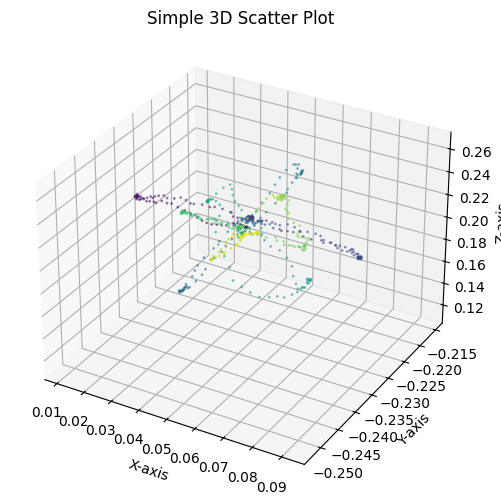

In [42]:

# 2. Create a figure and a 3D axes object
fig = plt.figure(figsize=(8, 6)) # Adjust figure size as needed
ax = fig.add_subplot(111, projection='3d') # '111' means 1 row, 1 column, first subplot
# 3. Plot the trajectory in 3D
traj_use = traj[100:700]
ax.scatter(traj_use[:, 0, 3], traj_use[:, 1, 3], traj_use[:, 2, 3], s=1, c=np.arange(len(traj_use)), cmap='viridis', alpha=0.5)    
# 4. Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Simple 3D Scatter Plot')

# 5. Display the plot
plt.show()

In [44]:

# Extract translation (xyz)
xyz = traj_use[:, :3, 3]

# Extract rotation matrix and convert to roll, pitch, yaw (rpy)
rot_mats = traj_use[:, :3, :3]
rpy = R.from_matrix(rot_mats).as_euler('xyz', degrees=False)

# Concatenate xyz and rpy
xyzrpy = np.hstack((xyz, rpy))
print(xyzrpy.shape)
print(xyzrpy[:5])  # Show first 5 rows as a sample

(600, 6)
[[ 0.05148549 -0.23387812  0.21455127 -0.00733356 -0.01243027  0.00334916]
 [ 0.05140642 -0.23382704  0.21447511 -0.00682816 -0.01220004  0.00350981]
 [ 0.05143528 -0.23382737  0.21421337 -0.00719872 -0.01252729  0.00264318]
 [ 0.05133645 -0.23395568  0.21431164 -0.00726653 -0.0120032   0.00340678]
 [ 0.05121879 -0.23377456  0.21412755 -0.00683071 -0.01188893  0.00256108]]


In [45]:
save_path = "/home/zfei/codes/unitree_ws/universal_manipulation_interface/playground/temp/" + "SLAM_traj_xyzrpy.txt" 
# save to as frame_idx,pos_x,pos_y,pos_z,rot_x,rot_y,rot_z,gripper_width=0
id_xyzrpy_gripper = np.zeros((xyzrpy.shape[0], 8))
id_xyzrpy_gripper[:, 0] = np.arange(xyzrpy.shape[0])
id_xyzrpy_gripper[:, 1:7] = xyzrpy
id_xyzrpy_gripper[:, 7] = 0
np.savetxt(save_path, id_xyzrpy_gripper, delimiter=",", fmt="%d,%f,%f,%f,%f,%f,%f,%d")
print("Saved to", save_path)



Saved to /home/zfei/codes/unitree_ws/universal_manipulation_interface/playground/temp/SLAM_traj_xyzrpy.txt
